
# 🔎 Dataset Examples

Activation maximization asked:

> **“What kind of synthetic image could strongly excite this feature?”**

Now we ask the complementary question:

> ## **“Which real images from a dataset actually activate this feature most strongly?”**

<div align="center">
  <img src="https://raw.githubusercontent.com/Cohere-Labs-Community/vision-interpretability-toolkit/main/images/data_ex.png"
       width="100%">
</div>




---




## Setup

This notebook uses:

- **WebDataset** to stream ImageNet shards rather than downloading the full dataset up front,
- **Hugging Face** as the dataset source,
- **PyTorch** for model inference,
- and **Lucent's InceptionV1** so the layer naming stays consistent with the activation-maximization notebook.

A GPU is strongly recommended because the full dataset must pass through the model.


In [1]:
# ---------------------------------------------------------
# Install dependencies
# ---------------------------------------------------------

!pip -q install webdataset huggingface_hub torch-lucent


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 257.1/257.1 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 125.5 MB/s eta 0:00:00


In [2]:
# ---------------------------------------------------------
# Imports
# ---------------------------------------------------------

import heapq
import os
import pickle as pkl
import re
from pathlib import Path

import numpy as np
import torch
import webdataset as wds

from PIL import Image
from torch.utils.data import DataLoader
from torchvision import transforms
from lucent.modelzoo import inceptionv1




---




## Connect to the ImageNet stream

The dataset is streamed from the Hugging Face repository


In [3]:
# ---------------------------------------------------------
# Load Hugging Face token from Colab Secrets
# ---------------------------------------------------------

from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError(
        "Hugging Face token not found. "
        "Add a Colab secret named 'HF_TOKEN' and rerun this cell."
    )

os.environ["HF_TOKEN"] = HF_TOKEN

print("✓ Hugging Face token loaded from Colab Secrets")


✓ Hugging Face token loaded from Colab Secrets



### Preprocessing the dataset

Every image is prepared using the same ImageNet-style preprocessing before it enters InceptionV1:

```text
image
  ↓
resize shortest side to 256
  ↓
center crop to 224 × 224
  ↓
convert to tensor
  ↓
normalize RGB channels
```

Along with the tensor, we keep each sample's **WebDataset key**. That key becomes the identifier we use when recording and later retrieving the strongest examples.


In [4]:
# ---------------------------------------------------------
# Image preprocessing
# ---------------------------------------------------------

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


# ---------------------------------------------------------
# Convert each WebDataset sample to (tensor, key)
# ---------------------------------------------------------

def to_tensor(sample):
    """Extract an image and its unique dataset key."""

    img = (
        sample.get("jpg")
        or sample.get("jpeg")
        or sample.get("JPEG")
    )

    if img is None:
        return None

    key = sample.get("__key__", "")

    return preprocess(img), key


# ---------------------------------------------------------
# Build URLs for ImageNet training shards
# ---------------------------------------------------------

BASE_URL = (
    "https://huggingface.co/datasets/"
    "timm/imagenet-1k-wds/resolve/main/"
)

TRAIN_SHARDS = [
    f"{BASE_URL}imagenet1k-train-{i:04d}.tar?download=true"
    for i in range(1024)
]

URLS_TRAIN = [
    "pipe:curl -f -sSL --retry 20 --retry-delay 2 "
    '-H "Authorization: Bearer $HF_TOKEN" '
    f'"{url}"'
    for url in TRAIN_SHARDS
]


# ---------------------------------------------------------
# Stream and decode the dataset
# ---------------------------------------------------------

dataset_train = (
    wds.WebDataset(
        URLS_TRAIN,
        handler=wds.handlers.warn_and_continue,
    )
    .decode(
        "pil",
        handler=wds.handlers.warn_and_continue,
    )
    .map(
        to_tensor,
        handler=wds.handlers.warn_and_continue,
    )
    .select(lambda sample: sample is not None)
)


# ---------------------------------------------------------
# Batch the stream
# ---------------------------------------------------------

BATCH_SIZE = 128

dl_train = DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print(f"✓ ImageNet stream ready — batch size: {BATCH_SIZE}")


✓ ImageNet stream ready — batch size: 128


/usr/local/lib/python3.12/dist-packages/webdataset/compat.py:379: UserWarning: WebDataset(shardshuffle=...) is None; set explicitly to False or a number
  warnings.warn("WebDataset(shardshuffle=...) is None; set explicitly to False or a number")




---



## Load InceptionV1

We now pass **ImageNet-1K training images** through the pretrained InceptionV1 model.

The model is used only for **inference** — its weights remain frozen.

Images are streamed from ImageNet in batches and passed through the network while we capture the activations at a selected internal layer.

Later, we will compare these activation scores across the dataset to find:

> **Which real ImageNet images activate each channel most strongly?**


In [5]:
# ---------------------------------------------------------
# Select device
# ---------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {DEVICE}")


# ---------------------------------------------------------
# Load and freeze pretrained InceptionV1
# ---------------------------------------------------------

model = inceptionv1(pretrained=True).to(DEVICE).eval()

for parameter in model.parameters():
    parameter.requires_grad = False

print("✓ InceptionV1 loaded")


Using device: cuda
Downloading: "https://github.com/ProGamerGov/pytorch-old-tensorflow-models/raw/master/inception5h.pth" to /root/.cache/torch/hub/checkpoints/inception5h.pth


100%|██████████| 27.0M/27.0M [00:00<00:00, 373MB/s]


✓ InceptionV1 loaded



## Choose where to save the results

A full scan can take a long time, so this workflow is designed to be **resumable**.

Google Drive is useful here because:

- checkpoints survive Colab runtime restarts,
- already-saved images do not need to be regenerated,
- and the final FULL/CROP examples remain available after the session ends.


In [6]:
# ---------------------------------------------------------
# OPTIONAL: Mount Google Drive
# ---------------------------------------------------------

from google.colab import drive

if os.path.exists("/content/drive/MyDrive"):
    print("✓ Google Drive already mounted")
else:
    drive.mount("/content/drive")


Mounted at /content/drive



## Configure the search

The main choices are:

- **`LAYER_NAME`** — which internal representation to inspect,
- **`CHANNEL_START` / `CHANNEL_END`** — which channels to process,
- **`TOPK`** — how many strongest dataset examples to keep per channel,
- **`REDUCTION`** — how a spatial feature map becomes one score per image,
- **`CROP_FRAC`** — how large the saved crop should be relative to the 224 × 224 model input.

### Why `REDUCTION = "max"`?

A channel produces a **2D feature map**, not one scalar.

Using the spatial maximum asks:

> **“Did this feature appear strongly anywhere in the image?”**

Using the spatial mean instead asks:

> **“Was this feature active broadly across the image?”**

For finding localized visual features, `max` is often the more intuitive starting point.


In [7]:
# ---------------------------------------------------------
# Search configuration
# ---------------------------------------------------------

CFG = {
    "LAYER_NAME": "mixed3a",
    "CHANNEL_START": 0,
    "CHANNEL_END": 255,     # inclusive
    "TOPK": 10,             # Number of top-activating images to keep per
                            # channel-> 10 here for compute/storage efficiency;
                            # it is customizable
    "REDUCTION": "max",     # "max" or "mean"
    "OUT_ROOT": "/content/drive/MyDrive/Dataset_images",
    "CROP_FRAC": 0.25,      # Keep a 25% × 25% region around the
                            # strongest activation
}

print("Configuration")
print("-" * 40)

for key, value in CFG.items():
    print(f"{key:<16}: {value}")


Configuration
----------------------------------------
LAYER_NAME      : mixed3a
CHANNEL_START   : 0
CHANNEL_END     : 255
TOPK            : 10
REDUCTION       : max
OUT_ROOT        : /content/drive/MyDrive/Dataset_images
CROP_FRAC       : 0.25




---




## Recover the image and its strongest local region

The tensors entering the model are normalized. Before saving them as ordinary images, we **undo the normalization**.

For the crop, we use the chosen channel's feature map:

1. find the spatial position with the largest activation,
2. map that position back onto the 224 × 224 input image,
3. center a crop around that location.

The crop highlights the image region around the channel's strongest activation. It is an approximate localization, rather than an exact attribution of which pixels caused the response.


In [8]:
# ---------------------------------------------------------
# Image normalization constants
# ---------------------------------------------------------

MEAN = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

STD = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)


# ---------------------------------------------------------
# Convert a normalized tensor back to a PIL image
# ---------------------------------------------------------

def tensor_to_pil(x: torch.Tensor) -> Image.Image:
    """Undo normalization and convert CHW tensor → RGB PIL image."""

    x = x.detach().cpu()

    if x.dim() == 4:
        x = x[0]

    x = (x * STD + MEAN).clamp(0, 1)

    x = (
        x.permute(1, 2, 0).numpy() * 255
    ).astype(np.uint8)

    return Image.fromarray(x)


# ---------------------------------------------------------
# Crop around the strongest activation for one channel
# ---------------------------------------------------------

def crop_from_tensor_and_feat(
    img_tensor_norm: torch.Tensor,
    feat_single: torch.Tensor,
    channel_id: int,
    frac: float = 0.25,
) -> Image.Image:
    """
    Find the strongest spatial activation for one channel and
    return a crop centered near that location.
    """

    # Undo input normalization.
    img = (
        img_tensor_norm.detach().cpu() * STD + MEAN
    ).clamp(0, 1)

    img_np = (
        img.permute(1, 2, 0).numpy() * 255
    ).astype(np.uint8)

    H, W = img_np.shape[:2]

    # Select this channel's 2D feature map.
    act = (
        feat_single[channel_id]
        .detach()
        .cpu()
        .clamp(min=0)
    )

    h, w = act.shape

    # Locate its strongest spatial activation.
    flat_index = int(torch.argmax(act).item())

    iy = flat_index // w
    ix = flat_index % w

    # Map feature-map coordinates back to input-image coordinates.
    cy = int((iy + 0.5) * H / h)
    cx = int((ix + 0.5) * W / w)

    crop_h = max(1, int(H * frac))
    crop_w = max(1, int(W * frac))

    # Keep the requested crop size even when the maximum is near an edge.
    y0 = min(
        max(0, cy - crop_h // 2),
        max(0, H - crop_h),
    )
    x0 = min(
        max(0, cx - crop_w // 2),
        max(0, W - crop_w),
    )

    y1 = y0 + crop_h
    x1 = x0 + crop_w

    return Image.fromarray(
        img_np[y0:y1, x0:x1]
    )



## Turn each feature map into one image-level score

For a batch of images, the hooked layer returns activations shaped:

```text
[B, C, H, W]

B = images in the batch
C = channels in the layer
H × W = spatial feature map
```

To rank dataset images for every channel, we reduce each `H × W` feature map to one scalar.

The result has shape:

```text
[B, C]
```

Now every image has one activation score for every channel.


In [9]:
# ---------------------------------------------------------
# Reduce spatial feature maps to one score per channel
# ---------------------------------------------------------

@torch.no_grad()
def reduce_all_channels(
    feat: torch.Tensor,
    reduction: str,
) -> torch.Tensor:
    """Convert [B, C, H, W] activations → [B, C] scores."""

    if reduction == "max":
        return feat.amax(dim=(2, 3))

    if reduction == "mean":
        return feat.mean(dim=(2, 3))

    raise ValueError(
        "reduction must be either 'max' or 'mean'"
    )



# Pass 1 — Find the top activating dataset keys 🏆

The first pass scans the dataset **once**.

For every selected channel, we maintain a small **min-heap** containing only the current top-$k$ examples.

### Resuming long scans

The current heap state is periodically saved to a checkpoint on Drive.

If the runtime stops and the same configuration is used again, the notebook reloads the checkpoint and skips batches that were already processed.

> For reliable resuming, keep the dataset shard ordering, batch size, layer, channel range, and `TOPK` unchanged.


In [10]:
# ---------------------------------------------------------
# Checkpoint configuration
# ---------------------------------------------------------

CKPT_PATH = os.path.join(
    CFG["OUT_ROOT"],
    f"{CFG['LAYER_NAME']}_topk_scan_ckpt.pkl",
)

SAVE_EVERY = 50


# ---------------------------------------------------------
# Save checkpoint atomically
# ---------------------------------------------------------

def save_ckpt(
    path,
    step,
    heaps,
    ch0,
    ch1,
    layer_name,
):
    """Persist the current top-k heaps so a scan can resume later."""

    os.makedirs(
        os.path.dirname(path),
        exist_ok=True,
    )

    tmp_path = path + ".tmp"

    checkpoint = {
        "step": step,
        "heaps": heaps,
        "ch0": ch0,
        "ch1": ch1,
        "layer_name": layer_name,
        "channel_start": CFG["CHANNEL_START"],
        "channel_end": CFG["CHANNEL_END"],
        "topk": CFG["TOPK"],
        "reduction": CFG["REDUCTION"],
        "batch_size": dl_train.batch_size,
    }

    with open(tmp_path, "wb") as f:
        pkl.dump(checkpoint, f)
        f.flush()
        os.fsync(f.fileno())

    # Atomic replacement avoids leaving a half-written checkpoint.
    os.replace(tmp_path, path)


# ---------------------------------------------------------
# Load checkpoint when available
# ---------------------------------------------------------

def load_ckpt(path):
    """Return a saved checkpoint, or None if it does not exist."""

    if not os.path.exists(path):
        return None

    with open(path, "rb") as f:
        return pkl.load(f)


# ---------------------------------------------------------
# Scan the dataset and keep top-k keys for each channel
# ---------------------------------------------------------

def scan_topk_keys(
    model,
    dl_train,
    device,
    layer_name: str,
    channel_start: int,
    channel_end_inclusive: int,
    topk: int,
    reduction: str,
):
    """
    Scan the dataset once and keep only the top-k activating
    dataset keys for every selected channel.
    """

    activation = {}

    # Capture the chosen layer's output during a normal forward pass.
    def hook_fn(module, inputs, output):
        activation["feat"] = output

    modules = dict(model.named_modules())

    if layer_name not in modules:
        raise KeyError(
            f"Layer '{layer_name}' was not found in the model."
        )

    handle = modules[layer_name].register_forward_hook(hook_fn)

    model.eval()

    heaps = None
    ch0 = None
    ch1 = None
    start_step = 0

    # -----------------------------------------------------
    # Resume a matching previous scan when possible
    # -----------------------------------------------------

    ckpt = load_ckpt(CKPT_PATH)

    if ckpt is not None:

        same_run = (
            ckpt.get("layer_name") == layer_name
            and ckpt.get("channel_start") == channel_start
            and ckpt.get("channel_end") == channel_end_inclusive
            and ckpt.get("topk") == topk
            and ckpt.get("reduction") == reduction
            and ckpt.get("batch_size") == dl_train.batch_size
        )

        if same_run:
            start_step = int(ckpt["step"]) + 1
            heaps = ckpt["heaps"]
            ch0 = int(ckpt["ch0"])
            ch1 = int(ckpt["ch1"])

            print(
                "Checkpoint found. "
                f"Resuming after batch {ckpt['step']}."
            )

        else:
            print(
                "Checkpoint belongs to a different configuration. "
                "Starting a fresh scan."
            )

    last_step = start_step - 1

    try:

        with torch.no_grad():

            for step, (imgs, keys) in enumerate(dl_train):

                # Skip batches already represented by the checkpoint.
                if step < start_step:
                    continue

                last_step = step

                imgs = imgs.to(
                    device,
                    non_blocking=True,
                )

                # Mixed precision speeds up GPU inference.
                with torch.autocast(
                    device_type=device.type,
                    enabled=(device.type == "cuda"),
                ):
                    _ = model(imgs)

                feat = activation["feat"]  # [B, C, H, W]

                B, C = feat.shape[:2]

                # -------------------------------------------------
                # Initialize one min-heap per requested channel
                # -------------------------------------------------

                if heaps is None:

                    ch0 = max(
                        0,
                        int(channel_start),
                    )

                    ch1 = min(
                        C - 1,
                        int(channel_end_inclusive),
                    )

                    if ch0 > ch1:
                        raise ValueError(
                            "Invalid channel range after clamping: "
                            f"[{ch0}, {ch1}] with C={C}"
                        )

                    heaps = {
                        c: []
                        for c in range(ch0, ch1 + 1)
                    }

                    print(
                        f"Scanning layer={layer_name} "
                        f"with {C} channels; "
                        f"selected range=[{ch0}, {ch1}]"
                    )

                # -------------------------------------------------
                # Validate a resumed channel range
                # -------------------------------------------------

                else:

                    ch0 = max(
                        0,
                        min(ch0, C - 1),
                    )

                    ch1 = max(
                        0,
                        min(ch1, C - 1),
                    )

                    if ch0 > ch1:
                        raise ValueError(
                            "Checkpoint channel range is invalid "
                            f"for this layer: [{ch0}, {ch1}] with C={C}"
                        )

                # -------------------------------------------------
                # Score every channel for every image in the batch
                # -------------------------------------------------

                scores_bc = reduce_all_channels(
                    feat,
                    reduction,
                ).float()  # [B, C]

                scores_sel = scores_bc[
                    :,
                    ch0:ch1 + 1,
                ]  # [B, selected channels]

                # Only the top-k items from a batch can possibly enter
                # that channel's global top-k heap.
                k = min(topk, B)

                vals, idxs = torch.topk(
                    scores_sel,
                    k=k,
                    dim=0,
                )  # [k, selected channels]

                vals = vals.detach().cpu()
                idxs = idxs.detach().cpu()

                # -------------------------------------------------
                # Update each channel's global top-k heap
                # -------------------------------------------------

                for offset, channel in enumerate(
                    range(ch0, ch1 + 1)
                ):

                    heap = heaps[channel]

                    for j in range(k):

                        score = float(
                            vals[j, offset].item()
                        )

                        batch_index = int(
                            idxs[j, offset].item()
                        )

                        key = keys[batch_index]

                        item = (score, key)

                        if len(heap) < topk:
                            heapq.heappush(
                                heap,
                                item,
                            )

                        elif score > heap[0][0]:
                            heapq.heapreplace(
                                heap,
                                item,
                            )

                # -------------------------------------------------
                # Progress reporting
                # -------------------------------------------------

                if (step + 1) % 50 == 0:

                    sample_channel = ch0

                    if heaps[sample_channel]:
                        print(
                            f"batches={step + 1} | "
                            f"ch{sample_channel} "
                            f"current top-{topk} floor="
                            f"{heaps[sample_channel][0][0]:.4f}"
                        )

                # -------------------------------------------------
                # Periodic checkpoint
                # -------------------------------------------------

                if (step + 1) % SAVE_EVERY == 0:

                    save_ckpt(
                        CKPT_PATH,
                        step,
                        heaps,
                        ch0,
                        ch1,
                        layer_name,
                    )

                    print(
                        f"Checkpoint saved after batch {step}"
                    )

    except KeyboardInterrupt:
        print("\nRun interrupted manually.")

    finally:

        # Save the newest valid state before leaving.
        if (
            heaps is not None
            and last_step >= start_step
        ):
            save_ckpt(
                CKPT_PATH,
                last_step,
                heaps,
                ch0,
                ch1,
                layer_name,
            )

            print(
                f"Latest state saved after batch {last_step}"
            )

        handle.remove()

    if heaps is None:
        raise RuntimeError(
            "No dataset batches were processed."
        )

    # Highest activation first.
    topk_by_channel = {
        channel: sorted(
            heap,
            key=lambda item: item[0],
            reverse=True,
        )
        for channel, heap in heaps.items()
    }

    return topk_by_channel



# Pass 2 — Retrieve and save the winning images 🖼️

Pass 1 intentionally stores only lightweight dataset keys and scores.

Now we stream the dataset a **second time** and wait until one of those winning keys appears.

When it does, we save:

```text
rank01_FULL_...jpg
rank01_CROP_...jpg
rank02_FULL_...jpg
rank02_CROP_...jpg
...
```

inside a folder for that channel.

### Why a second pass?

Keeping full images in memory during the scoring pass would make the search much heavier.

The two-pass design separates:

1. **ranking** — cheap metadata only,
2. **retrieval** — save only the small number of images that actually won.

The saving stage is also resumable. If the exact FULL/CROP pair already exists, it is skipped.


In [11]:
# ---------------------------------------------------------
# Map winning keys back to channels, scores, and ranks
# ---------------------------------------------------------

def map_top_keys(topk_by_channel):
    """Build lookup tables needed during the second dataset pass."""

    wanted_keys = set()
    key_to_targets = {}

    for channel, items in topk_by_channel.items():

        for rank, (score, key) in enumerate(
            items,
            start=1,
        ):

            wanted_keys.add(key)

            key_to_targets.setdefault(
                key,
                [],
            ).append(
                (channel, float(score), rank)
            )

    return wanted_keys, key_to_targets


# ---------------------------------------------------------
# Make dataset keys safe to use inside filenames
# ---------------------------------------------------------

def safe_filename(
    value: str,
    max_len: int = 120,
) -> str:
    """Sanitize a dataset key before inserting it into a filename."""

    value = (
        str(value)
        .replace("/", "_")
        .replace("\\", "_")
    )

    value = re.sub(
        r"[^a-zA-Z0-9._-]+",
        "_",
        value,
    )

    return value[:max_len]


# ---------------------------------------------------------
# Re-stream the dataset and save only the winning examples
# ---------------------------------------------------------

@torch.no_grad()
def save_topk_images_wds_streaming(
    model,
    dl_train,
    device,
    layer_name: str,
    topk_by_channel: dict,
    out_root: str,
    crop_frac: float,
):
    """
    Retrieve top-k dataset examples and save one FULL/CROP pair
    for each rank of every selected channel.
    """

    wanted_keys, key_to_targets = map_top_keys(
        topk_by_channel
    )

    layer_dir = os.path.join(
        out_root,
        layer_name,
    )

    os.makedirs(
        layer_dir,
        exist_ok=True,
    )

    # -----------------------------------------------------
    # Determine the exact filenames expected for this run
    # -----------------------------------------------------

    expected_paths_by_channel = {}

    for key in wanted_keys:

        key_safe = safe_filename(key)

        for channel, score, rank in key_to_targets[key]:

            ch_dir = os.path.join(
                layer_dir,
                f"ch_{channel:04d}",
            )

            expected_paths_by_channel.setdefault(
                channel,
                set(),
            ).update({
                os.path.join(
                    ch_dir,
                    f"rank{rank:02d}_FULL_"
                    f"score{score:.4f}_{key_safe}.jpg",
                ),
                os.path.join(
                    ch_dir,
                    f"rank{rank:02d}_CROP_"
                    f"score{score:.4f}_{key_safe}.jpg",
                ),
            })

    # -----------------------------------------------------
    # Remove stale rank images left by older runs
    # -----------------------------------------------------

    for channel, expected_paths in (
        expected_paths_by_channel.items()
    ):

        ch_dir = os.path.join(
            layer_dir,
            f"ch_{channel:04d}",
        )

        if not os.path.isdir(ch_dir):
            continue

        for filename in os.listdir(ch_dir):

            is_rank_image = (
                filename.startswith("rank")
                and (
                    "_FULL_" in filename
                    or "_CROP_" in filename
                )
                and filename.lower().endswith(".jpg")
            )

            path = os.path.join(
                ch_dir,
                filename,
            )

            if (
                is_rank_image
                and path not in expected_paths
            ):
                os.remove(path)

    # -----------------------------------------------------
    # Work out which dataset keys still need to be saved
    # -----------------------------------------------------

    remaining = set()

    for key in wanted_keys:

        targets = key_to_targets[key]
        key_safe = safe_filename(key)

        key_complete = True

        for channel, score, rank in targets:

            ch_dir = os.path.join(
                layer_dir,
                f"ch_{channel:04d}",
            )

            full_path = os.path.join(
                ch_dir,
                f"rank{rank:02d}_FULL_"
                f"score{score:.4f}_{key_safe}.jpg",
            )

            crop_path = os.path.join(
                ch_dir,
                f"rank{rank:02d}_CROP_"
                f"score{score:.4f}_{key_safe}.jpg",
            )

            if (
                not os.path.exists(full_path)
                or not os.path.exists(crop_path)
            ):
                key_complete = False
                break

        if not key_complete:
            remaining.add(key)

    print(
        "Pass 2 resume: "
        f"{len(wanted_keys) - len(remaining)} samples "
        "already complete; "
        f"{len(remaining)} still needed."
    )

    if not remaining:
        print("✓ All top-k images are already saved.")
        return

    # -----------------------------------------------------
    # Hook the same layer used during scoring
    # -----------------------------------------------------

    activation = {}

    def hook_fn(module, inputs, output):
        activation["feat"] = output

    modules = dict(model.named_modules())

    if layer_name not in modules:
        raise KeyError(
            f"Layer '{layer_name}' was not found in the model."
        )

    handle = modules[layer_name].register_forward_hook(
        hook_fn
    )

    model.eval()

    try:

        # -------------------------------------------------
        # Stream until all winning keys have been recovered
        # -------------------------------------------------

        for step, (imgs, keys) in enumerate(dl_train):

            imgs = imgs.to(
                device,
                non_blocking=True,
            )

            with torch.autocast(
                device_type=device.type,
                enabled=(device.type == "cuda"),
            ):
                _ = model(imgs)

            feat = activation["feat"]

            # Which samples in this batch are winners?
            hit_indices = [
                i
                for i, key in enumerate(keys)
                if key in remaining
            ]

            if not hit_indices:

                if (step + 1) % 200 == 0:
                    print(
                        f"batches={step + 1} | "
                        f"remaining={len(remaining)}"
                    )

                continue

            # -------------------------------------------------
            # Save every winning sample in this batch
            # -------------------------------------------------

            for batch_index in hit_indices:

                key = keys[batch_index]
                key_safe = safe_filename(key)

                # The FULL image is shared if the same dataset
                # sample appears in multiple channels' top-k lists.
                pil_full = tensor_to_pil(
                    imgs[batch_index]
                )

                for (
                    channel,
                    score,
                    rank,
                ) in key_to_targets[key]:

                    ch_dir = os.path.join(
                        layer_dir,
                        f"ch_{channel:04d}",
                    )

                    os.makedirs(
                        ch_dir,
                        exist_ok=True,
                    )

                    # The crop is channel-specific because each channel
                    # may peak at a different spatial location.
                    pil_crop = crop_from_tensor_and_feat(
                        imgs[batch_index],
                        feat[batch_index],
                        channel,
                        frac=crop_frac,
                    )

                    pil_full.save(
                        os.path.join(
                            ch_dir,
                            f"rank{rank:02d}_FULL_"
                            f"score{score:.4f}_{key_safe}.jpg",
                        ),
                        quality=95,
                    )

                    pil_crop.save(
                        os.path.join(
                            ch_dir,
                            f"rank{rank:02d}_CROP_"
                            f"score{score:.4f}_{key_safe}.jpg",
                        ),
                        quality=95,
                    )

                remaining.remove(key)

            # -------------------------------------------------
            # Progress reporting
            # -------------------------------------------------

            if (step + 1) % 50 == 0:
                print(
                    f"batches={step + 1} | "
                    f"saved="
                    f"{len(wanted_keys) - len(remaining)}"
                    f"/{len(wanted_keys)} | "
                    f"remaining={len(remaining)}"
                )

            # Stop as soon as every winning key has been found.
            if not remaining:
                print(
                    f"✓ Done early at batch {step + 1}"
                )
                break

    finally:
        handle.remove()

    if remaining:
        print(
            f"Warning: {len(remaining)} winning dataset keys "
            "were not recovered during Pass 2."
        )

    print("Saved results →", layer_dir)




---




## Inspect one channel

Before using the generated dataset examples downstream, it is useful to visually inspect a channel.

The cell below displays each **FULL image beside its activation-centered CROP**.

Look for:

- recurring textures, shapes, colors, or object parts,
- whether the crop consistently isolates a related visual pattern,
- and cases where the channel appears to respond to several different concepts.

> A channel does not need to have one clean human-readable meaning.  
> Mixed or polysemantic behavior is itself an interpretability result.


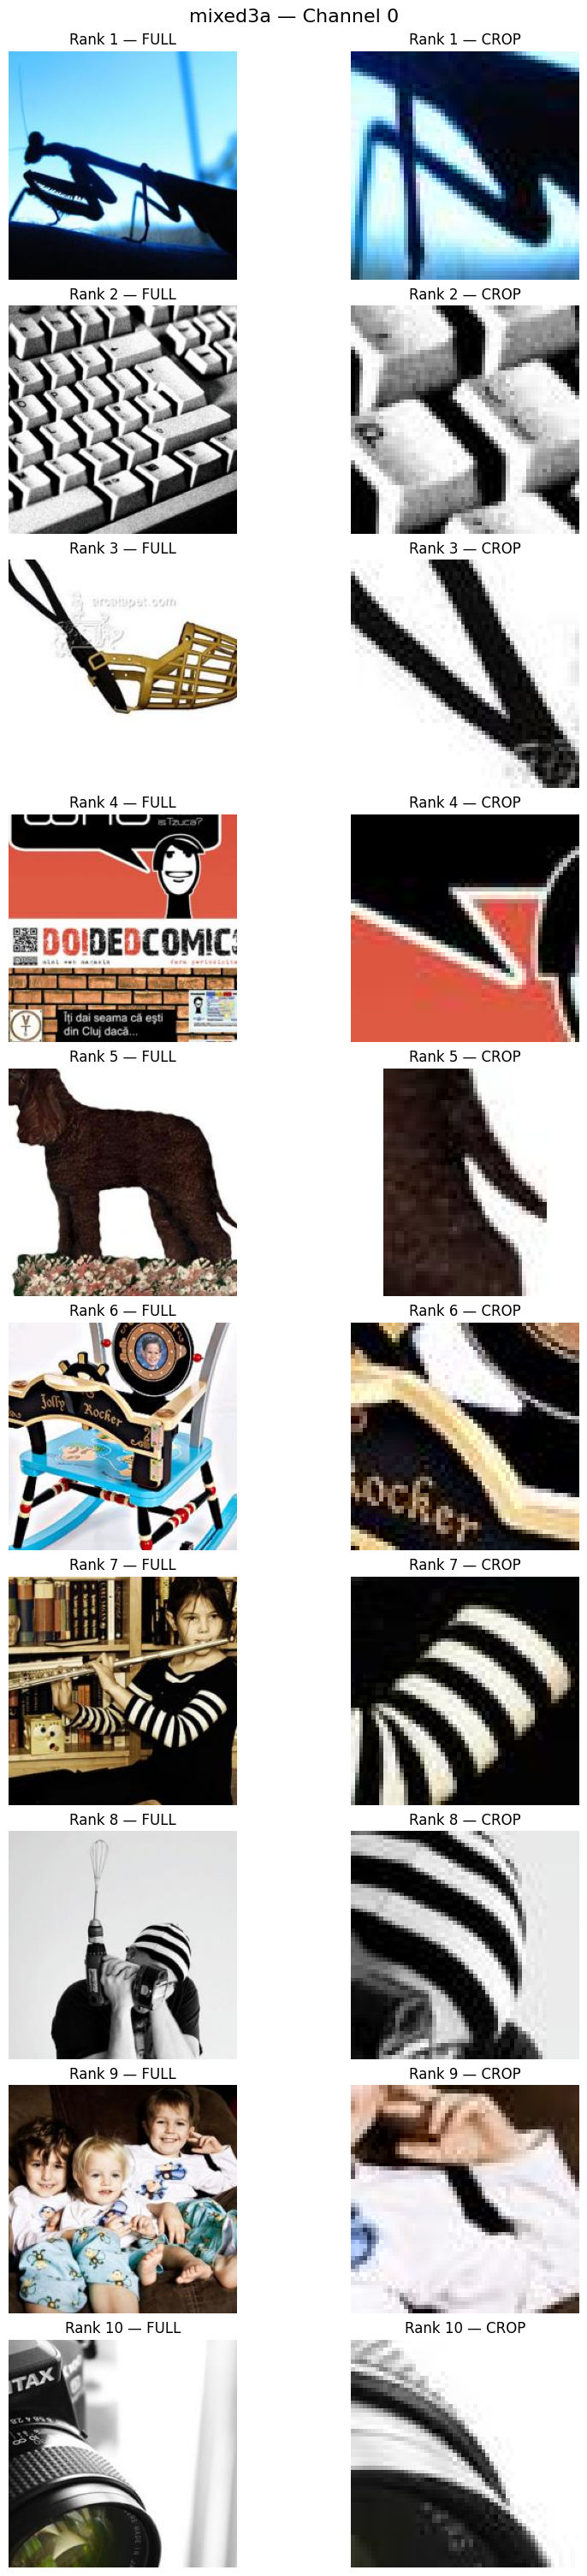

In [12]:
# ---------------------------------------------------------
# Display saved FULL/CROP pairs for one channel
# ---------------------------------------------------------

import matplotlib.pyplot as plt

CHANNEL_TO_VIEW = CFG["CHANNEL_START"]

channel_dir = os.path.join(
    CFG["OUT_ROOT"],
    CFG["LAYER_NAME"],
    f"ch_{CHANNEL_TO_VIEW:04d}",
)

full_files = sorted(
    [
        name
        for name in os.listdir(channel_dir)
        if "_FULL_" in name
        and name.lower().endswith(".jpg")
    ]
)

n = min(
    CFG["TOPK"],
    len(full_files),
)

if n == 0:
    raise FileNotFoundError(
        f"No saved examples found in {channel_dir}"
    )

fig, axes = plt.subplots(
    n,
    2,
    figsize=(8, 3 * n),
    constrained_layout=True,
)

# Matplotlib returns a 1D axes array when n == 1.
if n == 1:
    axes = np.array([axes])

for row, full_name in enumerate(full_files[:n]):

    crop_name = full_name.replace(
        "_FULL_",
        "_CROP_",
    )

    full_img = Image.open(
        os.path.join(
            channel_dir,
            full_name,
        )
    )

    crop_img = Image.open(
        os.path.join(
            channel_dir,
            crop_name,
        )
    )

    axes[row, 0].imshow(full_img)
    axes[row, 0].set_title(
        f"Rank {row + 1} — FULL"
    )
    axes[row, 0].axis("off")

    axes[row, 1].imshow(crop_img)
    axes[row, 1].set_title(
        f"Rank {row + 1} — CROP"
    )
    axes[row, 1].axis("off")

fig.suptitle(
    f"{CFG['LAYER_NAME']} — Channel {CHANNEL_TO_VIEW}",
    fontsize=16,
)

plt.show()




---




## Run the two-pass search




In [ ]:
# ---------------------------------------------------------
# Pass 1: identify the top activating dataset keys
# ---------------------------------------------------------

topk_by_channel = scan_topk_keys(
    model=model,
    dl_train=dl_train,
    device=DEVICE,
    layer_name=CFG["LAYER_NAME"],
    channel_start=CFG["CHANNEL_START"],
    channel_end_inclusive=CFG["CHANNEL_END"],
    topk=CFG["TOPK"],
    reduction=CFG["REDUCTION"],
)


# ---------------------------------------------------------
# Pass 2: retrieve and save FULL/CROP image pairs
# ---------------------------------------------------------

save_topk_images_wds_streaming(
    model=model,
    dl_train=dl_train,
    device=DEVICE,
    layer_name=CFG["LAYER_NAME"],
    topk_by_channel=topk_by_channel,
    out_root=CFG["OUT_ROOT"],
    crop_frac=CFG["CROP_FRAC"],
)




---



# Explore the features interactively ❇

We now have two complementary views of InceptionV1's internal features:


**Activation Maximization**  --> *What kind of synthetic pattern strongly activates this channel?*

**Dataset Examples**  --> *Which real images activate this channel most strongly?*

We brought these two views together in an interactive **InceptionV1 feature explorer**, where you can move across layers and channels and inspect their activation-maximization visualizations alongside their top-activating ImageNet examples.

<br>

<div align="center">

## 🔬 [Explore the InceptionV1 Feature Explorer](https://akankshanc-inception-v1-microscope.static.hf.space/)

*Choose a layer → select a channel → explore what it responds to.*

</div>




---

